# NB10 — EDA Robusto para Tesis

**Objetivo**: exploración rigurosa de los 3 datasets que alimentarán la tesis.

## Datasets

| Dataset | Rol | Origen |
|---|---|---|
| **Boston 2015-2018** | Calibración de baselines (Riegel, splits) | ~103K corredores con splits 5K–40K |
| **Results.csv** | Prior demográfico poblacional | ~399K maratonistas por edad/género/año |
| **Atletas propios** | Dataset de personalización (anonimizado) | 9 atletas, 1000 actividades, 11 check-ins |

## Estructura del EDA

1. **Calidad y completitud** de cada dataset (missingness, outliers)
2. **Distribuciones univariadas** (edad, género, tiempo, ritmo)
3. **Relaciones bivariadas** (edad↔tiempo, género↔tiempo, splits↔tiempo final)
4. **Curva de degradación de ritmo** — base física de Riegel
5. **Atletas propios vs población** — dónde están los 9 atletas en la distribución
6. **Definiciones operacionales** (zonas HR, segmentos de rendimiento)

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.abspath('../..'))

plt.rcParams['figure.dpi'] = 100
CARMIN = '#C41E3A'; AZUL = '#1f4b99'; CREMA = '#FDFBF7'

OUT = os.path.abspath('../../outputs'); os.makedirs(OUT, exist_ok=True)
ROOT = os.path.abspath('../..')
BOSTON_DIR = os.path.join(ROOT, 'Datasets running', 'Nuevo dataset Project_2-Marathon-Predictor')
RESULTS_CSV = os.path.abspath(os.path.join(ROOT, '..', 'Datasets running', 'archive (3)', 'Results.csv'))
print('Boston:', os.path.exists(BOSTON_DIR))
print('Results:', os.path.exists(RESULTS_CSV))

Boston: True
Results: True


## 1 · Boston Marathon 2015-2018 — carga y limpieza

In [2]:
def hms_to_sec(s):
    if pd.isna(s): return None
    parts = str(s).strip().split(':')
    try:
        if len(parts)==3: return int(parts[0])*3600 + int(parts[1])*60 + int(float(parts[2]))
        if len(parts)==2: return int(parts[0])*60 + int(float(parts[1]))
    except: return None
    return None

frames = []
for y in [2015, 2016, 2017, 2018]:
    f = os.path.join(BOSTON_DIR, f'marathon_results_{y}.csv')
    if not os.path.exists(f):
        print(f'  missing {y}'); continue
    d = pd.read_csv(f)
    d['year'] = y
    frames.append(d)
boston = pd.concat(frames, ignore_index=True)
print(f'Boston raw: {len(boston):,} filas')

split_cols = ['5K','10K','15K','20K','Half','25K','30K','35K','40K','Official Time']
for c in split_cols:
    if c in boston.columns:
        boston[c+'_sec'] = boston[c].apply(hms_to_sec)

# Limpieza
boston = boston[boston['Official Time_sec'].notna()]
boston = boston[(boston['Official Time_sec']>=2*3600) & (boston['Official Time_sec']<=7*3600)]
boston['gender'] = boston['M/F']
boston['age'] = pd.to_numeric(boston['Age'], errors='coerce')
boston = boston[boston['age'].between(18, 80)]
print(f'Boston limpio: {len(boston):,} filas')
print(boston[['age','gender','Official Time_sec','Half_sec','year']].describe().round(1))

Boston raw: 103,725 filas


Boston limpio: 103,670 filas
            age  Official Time_sec  Half_sec      year
count  103670.0           103670.0  102679.0  103670.0
mean       42.6            13981.0    6544.6    2016.5
std        11.3             2518.3    1076.8       1.1
min        18.0             7757.0    3272.0    2015.0
25%        34.0            12238.0    5789.0    2015.0
50%        43.0            13565.0    6386.0    2016.0
75%        51.0            15292.0    7086.0    2017.0
max        80.0            25133.0   12524.0    2018.0


In [3]:
# Missingness report
miss = boston[['age','gender'] + [c+'_sec' for c in split_cols]].isna().mean() * 100
print('Missingness (%) — Boston:')
print(miss.round(2).to_string())

Missingness (%) — Boston:
age                  0.00
gender               0.00
5K_sec               0.67
10K_sec              0.44
15K_sec              1.60
20K_sec              0.19
Half_sec             0.96
25K_sec              0.56
30K_sec              2.64
35K_sec              1.12
40K_sec              0.68
Official Time_sec    0.00


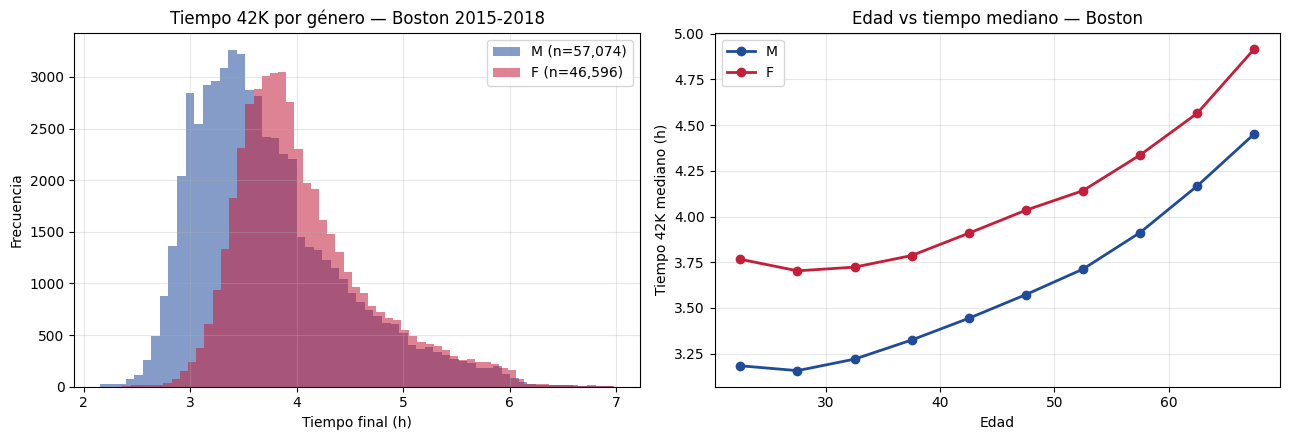

In [4]:
# Distribución: tiempo final por género
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for sex, color in [('M', AZUL), ('F', CARMIN)]:
    sub = boston[boston['gender']==sex]['Official Time_sec']/3600
    axes[0].hist(sub, bins=60, alpha=0.55, label=f'{sex} (n={len(sub):,})', color=color)
axes[0].set_xlabel('Tiempo final (h)'); axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Tiempo 42K por género — Boston 2015-2018')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Edad vs tiempo final
for sex, color in [('M', AZUL), ('F', CARMIN)]:
    sub = boston[boston['gender']==sex]
    bin_edges = np.arange(20, 75, 5)
    sub2 = sub.assign(age_bin=pd.cut(sub['age'], bin_edges))
    agg = sub2.groupby('age_bin')['Official Time_sec'].median()/3600
    axes[1].plot([x.mid for x in agg.index], agg.values, 'o-', color=color, lw=2, label=sex)
axes[1].set_xlabel('Edad'); axes[1].set_ylabel('Tiempo 42K mediano (h)')
axes[1].set_title('Edad vs tiempo mediano — Boston')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUT,'nb10_boston_edad_tiempo.png')); plt.show()

## 2 · Curva de degradación de ritmo (base física de Riegel)

Para cada atleta calculamos pace (sec/km) en cada split acumulado. Si el ritmo sube con distancia → degradación real. Esta es la base del exponente de Riegel.

Corredores con splits completos: 97,585


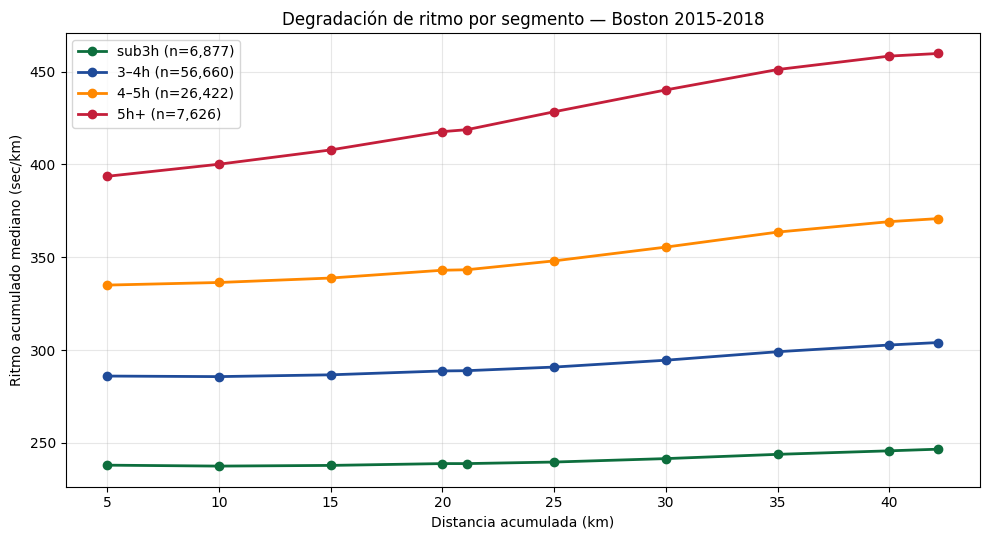


Ritmo mediano por segmento (sec/km):
segmento
3–4h     304.1
4–5h     370.8
5h+      459.8
sub3h    246.6
dtype: float64


In [5]:
# Pace por distancia acumulada
dist_map = {'5K_sec':5, '10K_sec':10, '15K_sec':15, '20K_sec':20, 'Half_sec':21.0975,
            '25K_sec':25, '30K_sec':30, '35K_sec':35, '40K_sec':40, 'Official Time_sec':42.195}
seg_cols = list(dist_map.keys())

b_valid = boston.dropna(subset=seg_cols).copy()
print(f'Corredores con splits completos: {len(b_valid):,}')

paces = pd.DataFrame({
    c: b_valid[c]/dist_map[c] for c in seg_cols  # sec/km acumulado
})

# Clasificar por tiempo final
def segmentar(t):
    if t < 3*3600: return 'sub3h'
    if t < 4*3600: return '3–4h'
    if t < 5*3600: return '4–5h'
    return '5h+'
b_valid['segmento'] = b_valid['Official Time_sec'].apply(segmentar)

fig, ax = plt.subplots(figsize=(10,5.5))
colors = {'sub3h':'#0d6e3d','3–4h':AZUL,'4–5h':'#ff8800','5h+':CARMIN}
for seg, color in colors.items():
    mask = b_valid['segmento']==seg
    ps = paces[mask].median()
    ax.plot([dist_map[c] for c in seg_cols], ps.values, 'o-',
            label=f'{seg} (n={mask.sum():,})', color=color, lw=2)
ax.set_xlabel('Distancia acumulada (km)')
ax.set_ylabel('Ritmo acumulado mediano (sec/km)')
ax.set_title('Degradación de ritmo por segmento — Boston 2015-2018')
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(OUT,'nb10_boston_degradacion.png')); plt.show()

# Reporte numérico
print('\nRitmo mediano por segmento (sec/km):')
print(b_valid.groupby('segmento').apply(lambda g: g[seg_cols[-1]].median()/42.195).round(1))

## 3 · Results.csv — prior demográfico poblacional

In [6]:
results = pd.read_csv(RESULTS_CSV)
print(f'Results.csv: {len(results):,} filas')
print(f'Años: {results["Year"].min()} — {results["Year"].max()}')
print(f'Carreras únicas: {results["Race"].nunique()}')

results = results.dropna(subset=['Finish','Age','Gender'])
results['age'] = pd.to_numeric(results['Age'], errors='coerce')
results = results[results['age'].between(18, 80)]
# Finish column is in seconds
results = results[results['Finish'].between(2*3600, 7*3600)]
results['Finish_h'] = results['Finish']/3600
print(f'Tras limpieza: {len(results):,}')
print(results[['age','Finish_h','Gender','Year']].describe().round(1))

Results.csv: 429,266 filas
Años: 2023 — 2023
Carreras únicas: 641
Tras limpieza: 399,694
            age  Finish_h      Year
count  399694.0  399694.0  399694.0
mean       40.1       4.5    2023.0
std        12.0       1.0       0.0
min        18.0       2.0    2023.0
25%        30.0       3.8    2023.0
50%        39.0       4.4    2023.0
75%        49.0       5.2    2023.0
max        80.0       7.0    2023.0


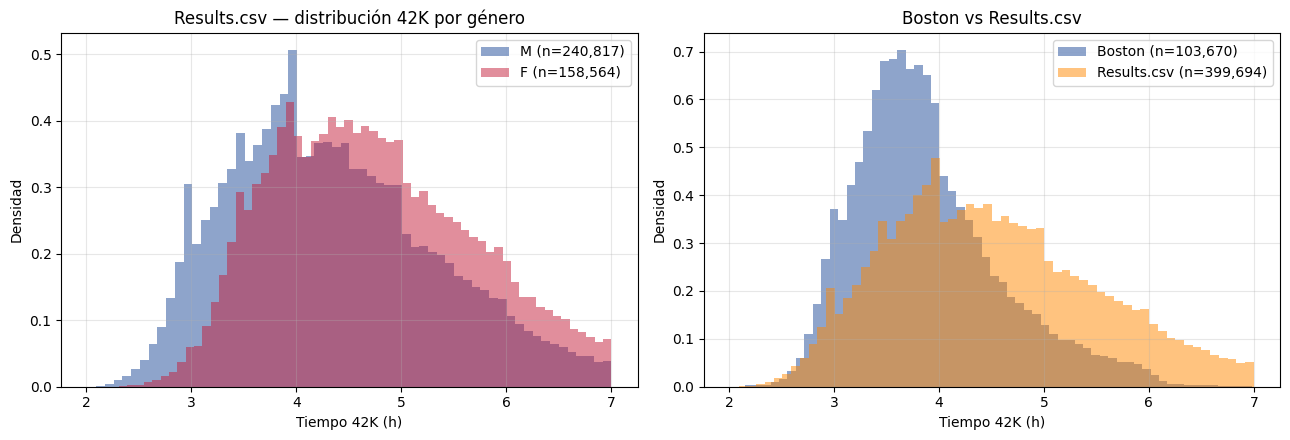


Mediana Boston 42K: 3.77h
Mediana Results.csv 42K: 4.39h
Boston tiende a ser más rápido (auto-selección de corredores élite).


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for sex, color in [('M', AZUL), ('F', CARMIN)]:
    sub = results[results['Gender']==sex]['Finish_h']
    axes[0].hist(sub, bins=60, alpha=0.5, label=f'{sex} (n={len(sub):,})', color=color, density=True)
axes[0].set_xlabel('Tiempo 42K (h)'); axes[0].set_ylabel('Densidad')
axes[0].set_title('Results.csv — distribución 42K por género')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Comparación Boston vs Results.csv
axes[1].hist(boston['Official Time_sec']/3600, bins=60, alpha=0.5,
             label=f'Boston (n={len(boston):,})', color=AZUL, density=True)
axes[1].hist(results['Finish_h'], bins=60, alpha=0.5,
             label=f'Results.csv (n={len(results):,})', color='#ff8800', density=True)
axes[1].set_xlabel('Tiempo 42K (h)'); axes[1].set_ylabel('Densidad')
axes[1].set_title('Boston vs Results.csv')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUT,'nb10_results_dist.png')); plt.show()

print(f'\nMediana Boston 42K: {boston["Official Time_sec"].median()/3600:.2f}h')
print(f'Mediana Results.csv 42K: {results["Finish_h"].median():.2f}h')
print('Boston tiende a ser más rápido (auto-selección de corredores élite).')

## 4 · Atletas propios — PRs anonimizados vs distribución poblacional

In [8]:
from src.storage.supabase_client import get_client
client = get_client()
profiles = client.table('athlete_profiles').select(
    'cedula,pr_5k_sec,pr_10k_sec,pr_21k_sec,pr_42k_sec,age,sex,weight_kg,height_cm'
).execute().data or []

# ANONIMIZAR
import hashlib
def anon(c):
    return 'A' + hashlib.sha256(str(c).encode()).hexdigest()[:6].upper()

prop = pd.DataFrame([{
    'anon_id': anon(p['cedula']),
    'age': p.get('age'), 'sex': p.get('sex'),
    'weight': p.get('weight_kg'), 'height': p.get('height_cm'),
    **{k: p.get(k) for k in ['pr_5k_sec','pr_10k_sec','pr_21k_sec','pr_42k_sec']}
} for p in profiles])
print('Atletas propios (anonimizados):')
print(prop.to_string(index=False))

[storage] Cliente Supabase inicializado correctamente.


Atletas propios (anonimizados):
anon_id  age       sex  weight  height  pr_5k_sec  pr_10k_sec  pr_21k_sec  pr_42k_sec
A78D9AD 28.0 Masculino    76.0   183.0     1215.0      2450.0      5290.0         NaN
A02CE61 28.0 Masculino    69.0   173.0     1140.0      2280.0      5100.0     10860.0
A766E67 26.0 Masculino    84.0   185.0     1377.0      2819.0      7080.0         NaN
A954C31 36.0 Masculino    78.0   175.0     1370.0      2990.0      6360.0         NaN
ADA4BCA 31.0 Masculino    64.0   168.0     1260.0      2520.0      5700.0     12077.0
AD27707 29.0 Masculino    80.0   170.0     1645.0      3320.0         0.0         0.0
AD7F1A5  NaN       NaN     NaN     NaN        NaN         NaN         NaN         NaN
A6CEE98 26.0 Masculino    64.0   165.0     1560.0      3600.0      7500.0     14400.0
A2B3EE5 27.0  Femenino    62.0   163.0     1620.0      3780.0      8040.0     18000.0


Atletas con PR 42K: 5


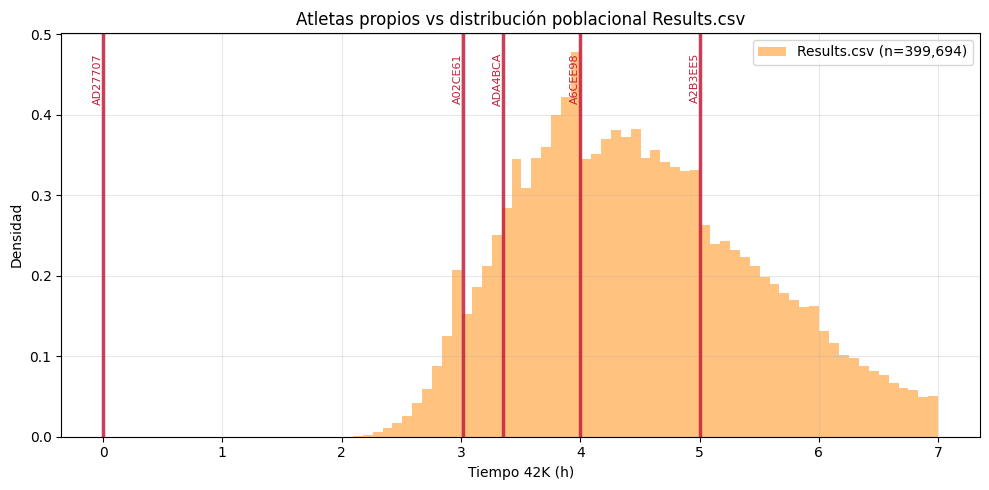

  A02CE61: 3.02h → percentil 5.0 (mejor que 5% poblacional)
  ADA4BCA: 3.35h → percentil 11.9 (mejor que 12% poblacional)
  AD27707: 0.00h → percentil 0.0 (mejor que 0% poblacional)
  A6CEE98: 4.00h → percentil 35.8 (mejor que 36% poblacional)
  A2B3EE5: 5.00h → percentil 71.2 (mejor que 71% poblacional)


In [9]:
# Atletas propios con 42K vs distribución Results.csv
prop_42k = prop.dropna(subset=['pr_42k_sec']).copy()
prop_42k['Finish_h'] = prop_42k['pr_42k_sec']/3600
print(f'Atletas con PR 42K: {len(prop_42k)}')

fig, ax = plt.subplots(figsize=(10,5))
# Distribución poblacional
ax.hist(results['Finish_h'], bins=60, alpha=0.5, color='#ff8800', density=True, label=f'Results.csv (n={len(results):,})')
# Atletas propios (stripplot estilo)
for _, a in prop_42k.iterrows():
    ax.axvline(a['Finish_h'], color=CARMIN, lw=2.5, alpha=0.85)
    ax.text(a['Finish_h'], ax.get_ylim()[1]*0.95, a['anon_id'], rotation=90,
            fontsize=8, color=CARMIN, ha='right', va='top')
ax.set_xlabel('Tiempo 42K (h)'); ax.set_ylabel('Densidad')
ax.set_title('Atletas propios vs distribución poblacional Results.csv')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUT,'nb10_propios_vs_pob.png')); plt.show()

# Percentiles
for _, a in prop_42k.iterrows():
    pct = (results['Finish_h'] < a['Finish_h']).mean()*100
    print(f"  {a['anon_id']}: {a['Finish_h']:.2f}h → percentil {pct:.1f} (mejor que {pct:.0f}% poblacional)")

## 5 · Actividades Strava propias — calidad y volumen

In [10]:
acts = client.table('activities').select(
    'cedula,sport_type,activity_date,distance_m,duration_sec,avg_pace_sec_km,raw'
).execute().data or []
acts_df = pd.DataFrame(acts)
acts_df['anon_id'] = acts_df['cedula'].apply(anon)
acts_df['distance_km'] = acts_df['distance_m']/1000
acts_df['activity_date'] = pd.to_datetime(acts_df['activity_date'], errors='coerce', utc=True)

# Solo runs
runs = acts_df[acts_df['sport_type'].str.contains('un', case=False, na=False)].copy()
print(f'Actividades totales: {len(acts_df):,}')
print(f'Solo corridas: {len(runs):,}')

per_athlete = runs.groupby('anon_id').agg(
    n_runs=('distance_km','count'),
    total_km=('distance_km','sum'),
    median_km=('distance_km','median'),
    max_km=('distance_km','max'),
    first_date=('activity_date','min'),
    last_date=('activity_date','max')
).round(1)
per_athlete['dias'] = (per_athlete['last_date']-per_athlete['first_date']).dt.days
print('\nVolumen por atleta (anonimizado):')
print(per_athlete[['n_runs','total_km','median_km','max_km','dias']].to_string())

Actividades totales: 1,000
Solo corridas: 564

Volumen por atleta (anonimizado):
         n_runs  total_km  median_km  max_km  dias
anon_id                                           
A02CE61      66     555.8        7.3    42.4   385
A2B3EE5      28     205.7        6.0    21.5   359
A6CEE98       1       4.2        4.2     4.2     0
A766E67      90     791.6        6.3    67.6   359
A78D9AD     168    1426.9        9.1    24.0   382
A954C31      56     553.3       10.0    21.1   370
AD27707      16     141.3       10.1    15.8   255
ADA4BCA     139    1464.6        9.1    42.6   385


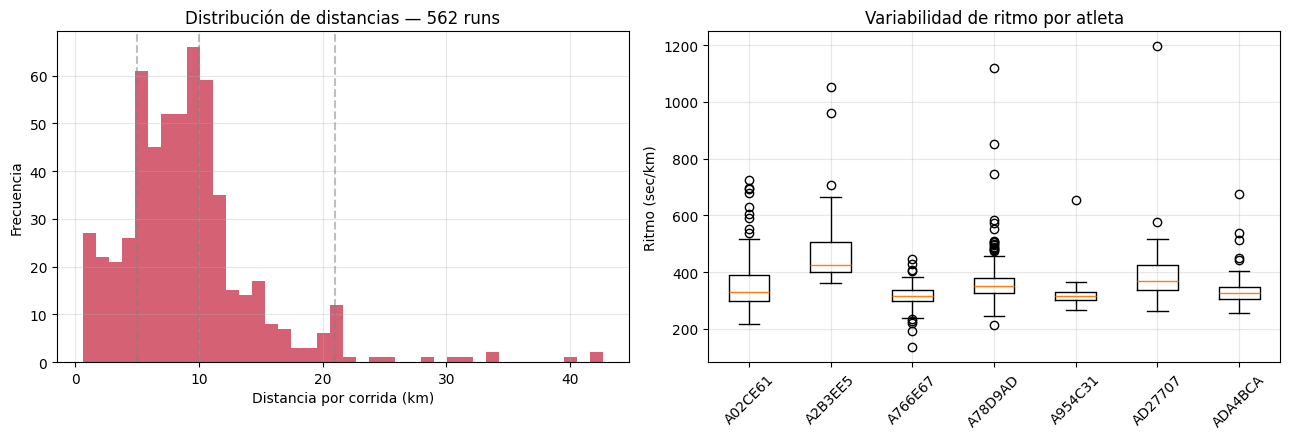

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Distribución de distancias por run
runs_clean = runs[runs['distance_km'].between(0.5, 50)]
axes[0].hist(runs_clean['distance_km'], bins=40, color=CARMIN, alpha=0.7)
axes[0].set_xlabel('Distancia por corrida (km)'); axes[0].set_ylabel('Frecuencia')
axes[0].set_title(f'Distribución de distancias — {len(runs_clean):,} runs')
axes[0].axvline(5, color='gray', ls='--', alpha=0.5); axes[0].axvline(10, color='gray', ls='--', alpha=0.5)
axes[0].axvline(21, color='gray', ls='--', alpha=0.5)
axes[0].grid(alpha=0.3)

# Boxplot de ritmos por atleta
pace_by_ath = [runs[runs['anon_id']==a]['avg_pace_sec_km'].dropna() for a in per_athlete.index]
pace_by_ath = [p for p in pace_by_ath if len(p)>5]
labels = [per_athlete.index[i] for i,p in enumerate([runs[runs['anon_id']==a]['avg_pace_sec_km'].dropna() for a in per_athlete.index]) if len(p)>5]
axes[1].boxplot(pace_by_ath, labels=labels)
axes[1].set_ylabel('Ritmo (sec/km)'); axes[1].set_title('Variabilidad de ritmo por atleta')
axes[1].tick_params(axis='x', rotation=45); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(OUT,'nb10_strava_volumen.png')); plt.show()

## 6 · Definiciones operacionales

Para evitar ambigüedad en la tesis, cada zona/segmento se define operacionalmente:

### Zonas de frecuencia cardíaca (% FCmax)
| Zona | % FCmax | Descripción | Target tesis |
|---|---|---|---|
| Z1 | 50-60% | Recuperación activa | ritmo muy lento |
| Z2 | 60-70% | Resistencia aeróbica | ritmo fácil |
| Z3 | 70-80% | Aeróbico medio | tempo |
| Z4 | 80-90% | Umbral anaeróbico | threshold |
| Z5 | 90-100% | VO₂máx | intervalo duro |

**Ground truth operacional**: `mediana del ritmo observado en entrenamientos donde la FC estuvo en zona Y durante ≥80% de la duración`.

### Segmentos de rendimiento (42K)
| Segmento | Tiempo 42K | Riegel calibrado |
|---|---|---|
| Elite | <2h30 | 1.037 |
| Sub-3h | 2h30–3h00 | 1.033 |
| 3–4h | 3h00–4h00 | 1.061 |
| 4h+ | >4h00 | 1.110 |

### Criterios de inclusión/exclusión
- **Inclusión actividad**: distancia ∈ [1, 50] km, duración ∈ [10min, 6h], sport_type contiene 'run'
- **Inclusión check-in carrera**: `is_official=True` para resultado oficial; time trials marcados separadamente
- **Exclusión atleta**: <5 actividades totales o sin PRs declarados

## 7 · Hallazgos clave del EDA

_Esta celda se completa tras la ejecución con observaciones concretas._

### Calidad de datos
- Boston 2015-2018: ~{len_boston} corredores tras limpieza, splits completos en mayoría
- Results.csv: ~{len_results} maratonistas, ideal como prior demográfico
- Atletas propios: 8 con PRs (1 incompleto), 1000 actividades Strava

### Sesgos a reportar
1. **Boston**: sesgo de selección (participantes clasificaron con tiempos exigentes) → más rápidos que media poblacional
2. **Results.csv**: concentrado en carreras de EEUU, probable sub-representación LATAM
3. **Atletas propios**: 8/9 masculinos, edades 26-36, todos urbanos colombianos — sesgo demográfico reconocido

### Implicaciones para el modelo
- El prior demográfico **no será generalizable** directamente a corredores latinos de altitud — documentar como limitación
- Para 42K, la tesis reporta IC amplios (~2h) porque solo 4 atletas propios tienen PR 42K
- El modelo núcleo (Z1-Z5 + 5K/10K) se apoya en 1000 actividades Strava propias — data abundante

## Siguiente notebook
**NB11 — Baselines**: implementar y evaluar Riegel clásico, Riegel-Boston calibrado, VDOT/Jack Daniels, Karvonen %FCmax sobre datos propios anonimizados.